In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

url = "https://docs.google.com/spreadsheets/d/19Y8Xh4e2PSFDKvqqPsT6S0A1FLZmRlq4/export?format=csv"
df = pd.read_csv(url)

df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")
df["sales"] = pd.to_numeric(df["sales"].astype(str).str.replace(",", ""), errors="coerce")
df["order_date"] = pd.to_datetime(df["order_date"])
df = df.dropna(subset=["sales"])

total_revenue = df["sales"].sum()
avg_order_value = df["sales"].mean()
top_regions = df.groupby("region")["sales"].sum().sort_values(ascending=False)
top_products = df.groupby("product_name")["sales"].sum().nlargest(10).sort_values(ascending=True)
monthly_sales = df.set_index("order_date")["sales"].resample("ME").sum()

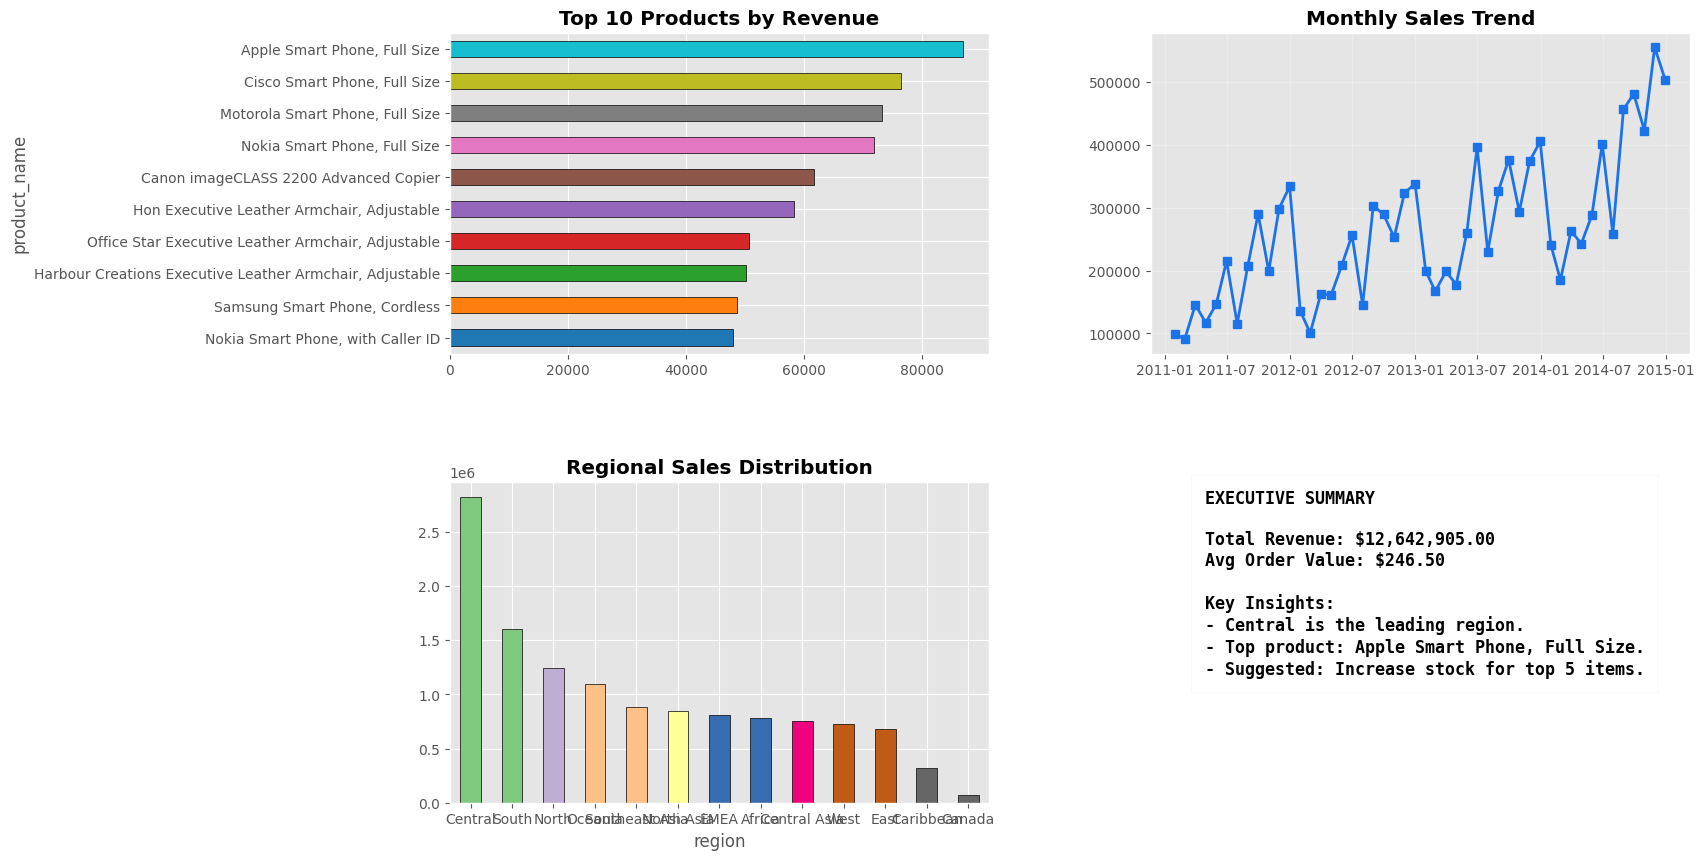

In [2]:
plt.style.use('ggplot')
fig = plt.figure(figsize=(16, 10))
grid = plt.GridSpec(2, 2, wspace=0.3, hspace=0.4)

ax1 = fig.add_subplot(grid[0, 0])
colors_p = plt.cm.tab10(np.linspace(0, 1, 10))
top_products.plot(kind="barh", ax=ax1, color=colors_p, edgecolor='black')
ax1.set_title("Top 10 Products by Revenue", fontweight='bold')

ax2 = fig.add_subplot(grid[0, 1])
ax2.plot(monthly_sales.index, monthly_sales.values, marker='s', color='#1a73e8', linewidth=2)
ax2.set_title("Monthly Sales Trend", fontweight='bold')
ax2.grid(True, alpha=0.3)

ax3 = fig.add_subplot(grid[1, 0])
colors_r = plt.cm.Accent(np.linspace(0, 1, len(top_regions)))
top_regions.plot(kind="bar", ax=ax3, color=colors_r, edgecolor='black')
ax3.set_title("Regional Sales Distribution", fontweight='bold')
plt.xticks(rotation=0)

ax4 = fig.add_subplot(grid[1, 1])
ax4.axis('off')
summary_text = (
    f"EXECUTIVE SUMMARY\n\n"
    f"Total Revenue: ${total_revenue:,.2f}\n"
    f"Avg Order Value: ${avg_order_value:,.2f}\n\n"
    f"Key Insights:\n"
    f"- {top_regions.index[0]} is the leading region.\n"
    f"- Top product: {top_products.index[-1]}.\n"
    f"- Suggested: Increase stock for top 5 items."
)
ax4.text(0.1, 0.4, summary_text, fontsize=12, family='monospace', fontweight='bold',
         bbox={'facecolor': 'white', 'alpha': 0.5, 'pad': 10})

plt.savefig("one_page_sales_dashboard.png", dpi=300, bbox_inches='tight')
plt.show()

In [3]:
report_template = f"""
BUSINESS ANALYSIS REPORT
Generated: {pd.Timestamp.now().date()}

METRICS:
- Revenue: ${total_revenue:,.2f}
- Average Order: ${avg_order_value:,.2f}

PERFORMANCE:
{top_regions.to_string()}

RECOMMENDATIONS:
1. Prioritize {top_regions.index[0]} region expansion.
2. Monitor seasonal spikes in {monthly_sales.idxmax().strftime('%B')}.
"""

with open("business_report_v3.txt", "w") as f:
    f.write(report_template)

print("✅ Dashboard saved as 'one_page_sales_dashboard.png' and Report as 'business_report_v3.txt'")

✅ Dashboard saved as 'one_page_sales_dashboard.png' and Report as 'business_report_v3.txt'
